# 🧪 시나리오: CORS & JWT 인증 정책 테스트

## 테스트 항목

| # | 정책 | 테스트 내용 | 기대 결과 |
|---|------|-----------|----------|
| 1 | CORS | CORS 미적용 상태 → OPTIONS Preflight 요청 | CORS 헤더 없음 |
| 2 | CORS | Portal에서 CORS 적용 → Preflight 성공 확인 | 200 + CORS 헤더 |
| 3 | CORS | 허용되지 않은 Origin → CORS 차단 | CORS 헤더 없음 |
| 4 | JWT | Azure AD 토큰 발급 & 검증 시뮬레이션 | 토큰 발급 확인 |

## 사전 조건
- Lab 1~2 완료 (APIM + Azure OpenAI 연결)
- `.env`에 `APIM_SUBSCRIPTION_KEY` 설정 완료
- JWT 테스트: Azure AD 앱 등록 (선택사항, 없으면 스킵됨)

## 진행 방식
> 이 노트북은 **Portal에서 직접 정책을 적용/제거**하며 테스트합니다.
> 코드가 자동으로 정책을 변경하지 않으므로, 각 테스트 전 안내에 따라 Portal에서 설정하세요.

In [36]:
import os
import requests
from dotenv import load_dotenv

load_dotenv("../../.env", override=True)

APIM_URL = os.getenv("APIM_URL")
SUBSCRIPTION_KEY = os.getenv("APIM_SUBSCRIPTION_KEY")
DEPLOYMENT_NAME = os.getenv("DEPLOYMENT_NAME", "gpt-4.1-nano")
API_VERSION = "2025-04-01-preview"

assert APIM_URL, "❌ APIM_URL이 설정되지 않았습니다."
assert SUBSCRIPTION_KEY, "❌ APIM_SUBSCRIPTION_KEY가 설정되지 않았습니다."

BASE_URL = f"{APIM_URL}/openai/deployments/{DEPLOYMENT_NAME}/chat/completions"
HEADERS = {
    "Content-Type": "application/json",
    "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY
}
BODY = {"messages": [{"role": "user", "content": "Hi"}], "max_tokens": 5}

results = {}

print("✅ 환경 설정 완료")
print(f"   APIM URL:    {APIM_URL}")
print(f"   Deployment:  {DEPLOYMENT_NAME}")

✅ 환경 설정 완료
   APIM URL:    https://apim-ai-gw-aigateway-20260317.azure-api.net
   Deployment:  gpt-4.1-nano


## 테스트 1: CORS Preflight 요청 (정책 미적용 상태)

CORS 정책이 없는 상태에서 OPTIONS 요청을 보내면 CORS 관련 헤더가 반환되지 않습니다.
브라우저는 이 경우 실제 POST 요청을 차단합니다.

> ⚠️ Portal에서 CORS 정책이 설정되어 있지 않은지 먼저 확인하세요.
> Azure Portal → APIM → APIs → Azure OpenAI → All operations → Inbound processing `</>`

In [38]:
print("▶ 테스트 1: CORS 미적용 상태 — OPTIONS Preflight\n")

resp = requests.options(
    BASE_URL,
    params={"api-version": API_VERSION},
    headers={
        "Origin": "http://localhost:3000",
        "Access-Control-Request-Method": "POST",
        "Access-Control-Request-Headers": "Content-Type, Ocp-Apim-Subscription-Key"
    },
    timeout=10
)

cors_header = resp.headers.get("Access-Control-Allow-Origin", None)
print(f"  HTTP Status: {resp.status_code}")
print(f"  Access-Control-Allow-Origin: {cors_header or '(없음)'}")
print(f"  Access-Control-Allow-Methods: {resp.headers.get('Access-Control-Allow-Methods', '(없음)')}")

if cors_header:
    print(f"\n  ℹ️ CORS가 이미 설정되어 있습니다. (Global 또는 API 레벨에서 설정됨)")
    results["CORS 미적용 확인"] = "⚠️ 이미 설정됨"
else:
    print(f"\n  ✅ CORS 미설정 확인 → 브라우저에서 요청 시 차단됨")
    results["CORS 미적용 확인"] = True

▶ 테스트 1: CORS 미적용 상태 — OPTIONS Preflight

  HTTP Status: 404
  Access-Control-Allow-Origin: (없음)
  Access-Control-Allow-Methods: (없음)

  ✅ CORS 미설정 확인 → 브라우저에서 요청 시 차단됨


## 테스트 2: CORS 정책 적용 → Preflight 성공 확인

### Portal에서 CORS 정책 추가

1. Azure Portal → APIM → **APIs** → **Azure OpenAI** → **All operations**
2. **Inbound processing** 영역의 **</>** 클릭 (Code View)
3. `<base />` 바로 아래에 다음 XML을 추가 → **Save**:

```xml
<cors allow-credentials="false">
    <allowed-origins>
        <origin>http://localhost:3000</origin>
        <origin>https://test-app.azurewebsites.net</origin>
    </allowed-origins>
    <allowed-methods>
        <method>POST</method>
        <method>OPTIONS</method>
    </allowed-methods>
    <allowed-headers>
        <header>Content-Type</header>
        <header>Ocp-Apim-Subscription-Key</header>
        <header>Authorization</header>
    </allowed-headers>
</cors>
```

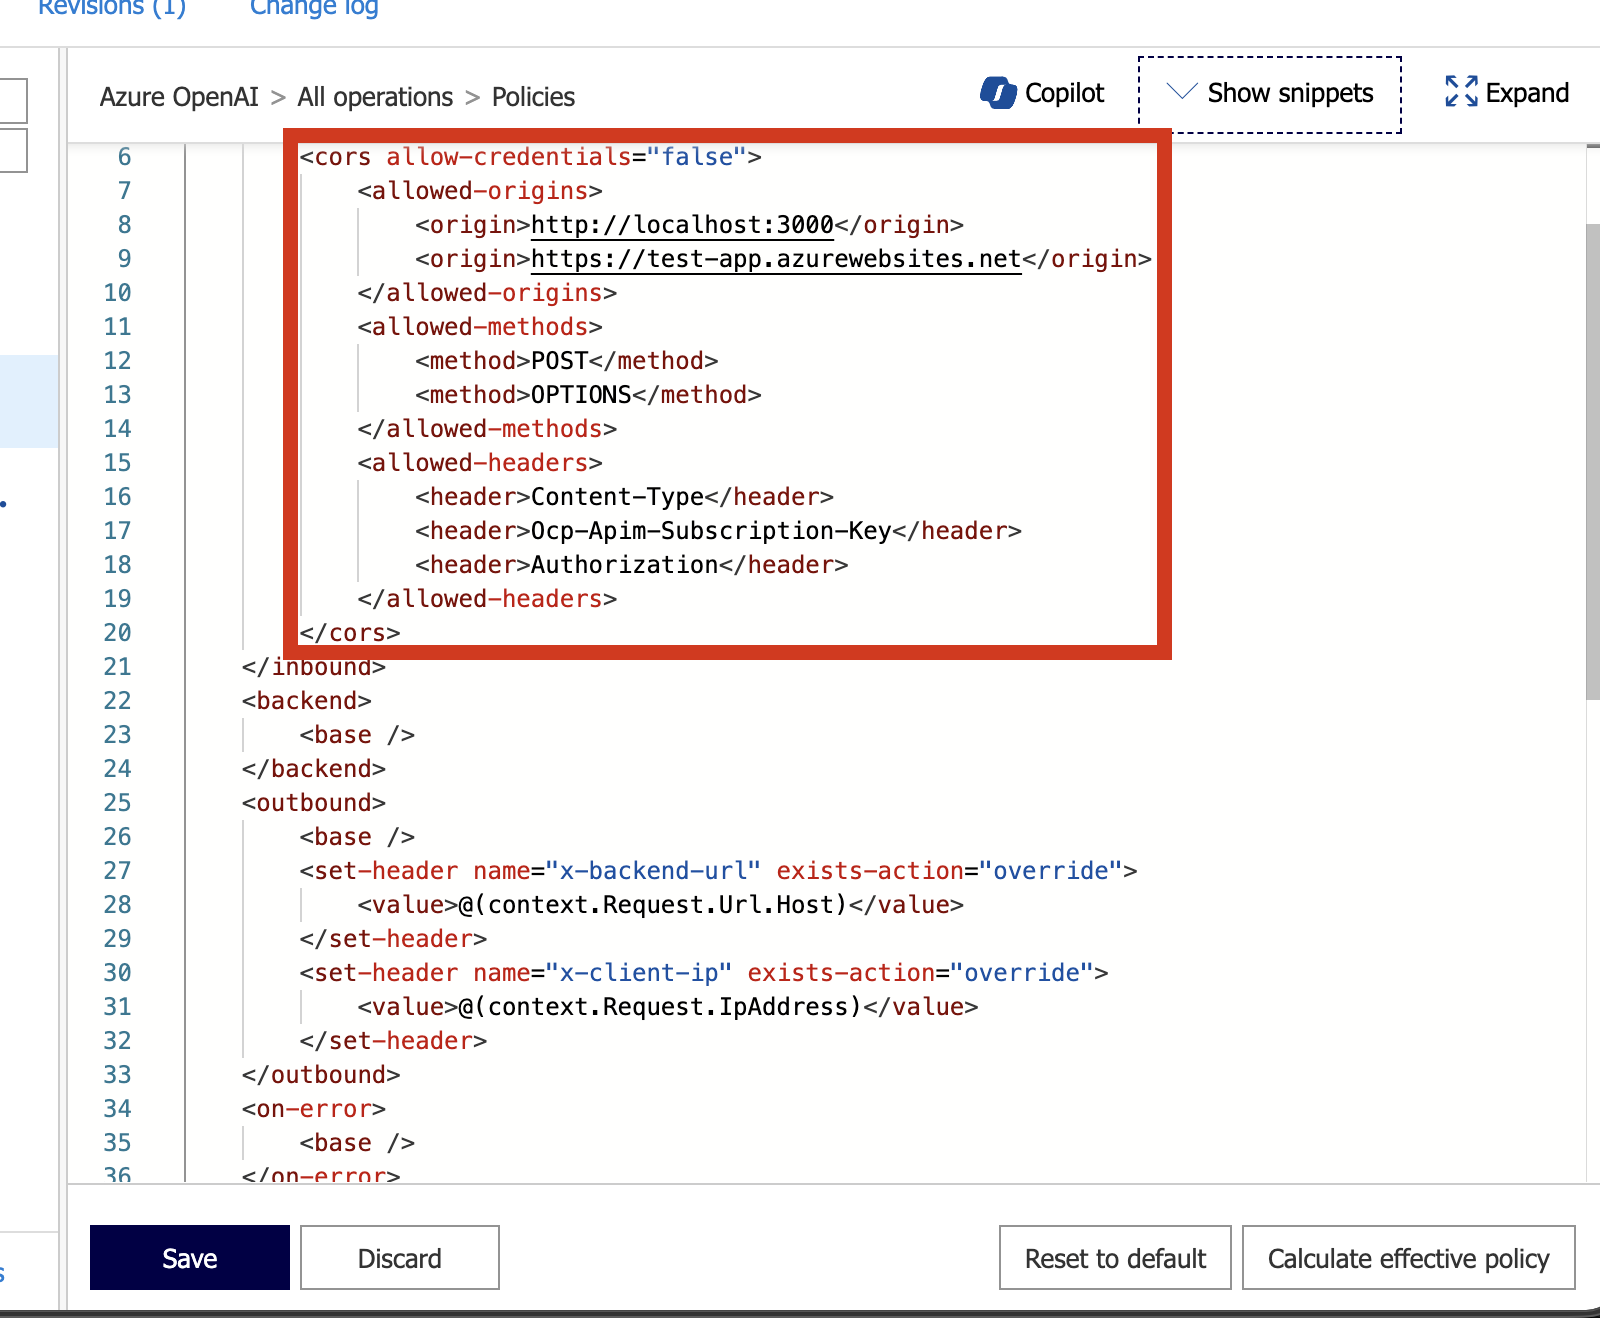

4. 저장 후 아래 셀을 실행하세요.

In [6]:
print("▶ 테스트 2: CORS 정책 적용 → Preflight 테스트\n")

input("  ⏸️ Portal에서 CORS 정책을 추가하고 Save 한 후 Enter를 누르세요...")
print()

resp = requests.options(
    BASE_URL,
    params={"api-version": API_VERSION},
    headers={
        "Origin": "http://localhost:3000",
        "Access-Control-Request-Method": "POST",
        "Access-Control-Request-Headers": "Content-Type, Ocp-Apim-Subscription-Key"
    },
    timeout=10
)

cors_origin = resp.headers.get("Access-Control-Allow-Origin", None)
cors_methods = resp.headers.get("Access-Control-Allow-Methods", None)
print(f"  HTTP Status: {resp.status_code}")
print(f"  Access-Control-Allow-Origin: {cors_origin or '(없음)'}")
print(f"  Access-Control-Allow-Methods: {cors_methods or '(없음)'}")

if cors_origin == "http://localhost:3000":
    print(f"\n  ✅ CORS 정상 동작! 브라우저에서 호출 가능")
    results["CORS 적용 테스트"] = True
else:
    print(f"\n  ❌ CORS 헤더 누락")
    print(f"     → Portal에서 CORS 정책이 정상 저장되었는지 확인하세요.")
    print(f"     → 저장 후 3~5초 대기 후 다시 실행해 보세요.")
    results["CORS 적용 테스트"] = False

▶ 테스트 2: CORS 정책 적용 → Preflight 테스트


  HTTP Status: 200
  Access-Control-Allow-Origin: http://localhost:3000
  Access-Control-Allow-Methods: POST

  ✅ CORS 정상 동작! 브라우저에서 호출 가능


## 테스트 3: 허용되지 않은 Origin에서 CORS 차단 확인

CORS 정책이 적용된 상태에서, 허용 목록에 없는 Origin(`https://evil-site.example.com`)으로 요청하면
CORS 헤더가 반환되지 않아 브라우저가 차단합니다.

> ℹ️ 테스트 2에서 적용한 CORS 정책이 그대로 유지된 상태에서 실행하세요.

In [17]:
print("▶ 테스트 3: 허용되지 않은 Origin — CORS 차단\n")

resp = requests.options(
    BASE_URL,
    params={"api-version": API_VERSION},
    headers={
        "Origin": "https://evil-site.example.com",
        "Access-Control-Request-Method": "POST",
        "Access-Control-Request-Headers": "Content-Type"
    },
    timeout=10
)

cors_origin = resp.headers.get("Access-Control-Allow-Origin", None)
print(f"  Origin: https://evil-site.example.com")
print(f"  HTTP Status: {resp.status_code}")
print(f"  Access-Control-Allow-Origin: {cors_origin or '(없음)'}")

if not cors_origin or cors_origin != "https://evil-site.example.com":
    print(f"\n  ✅ 비허용 Origin 차단 확인 → 브라우저에서 요청 불가")
    results["CORS 비허용 Origin 차단"] = True
else:
    print(f"\n  ❌ 비허용 Origin이 통과됨 — CORS 설정 확인 필요")
    results["CORS 비허용 Origin 차단"] = False

▶ 테스트 3: 허용되지 않은 Origin — CORS 차단

  Origin: https://evil-site.example.com
  HTTP Status: 404
  Access-Control-Allow-Origin: (없음)

  ✅ 비허용 Origin 차단 확인 → 브라우저에서 요청 불가


### 🔄 CORS 정책 제거 (원래 상태로 복원)

테스트가 끝났으면 Portal에서 CORS 정책을 제거하세요:

1. Azure Portal → APIM → **APIs** → **Azure OpenAI** → **All operations**
2. **Inbound processing** 영역의 **</>** 클릭
3. 테스트 2에서 추가한 `<cors>...</cors>` 블록 삭제 → **Save**

## 테스트 4: validate-jwt — Azure AD 토큰 검증

> ⚠️ 이 테스트는 Azure AD 앱 등록이 필요합니다. 설정하지 않았다면 스킵됩니다.
>
> **사전 준비:**
> 1. Azure Portal → Azure Active Directory → 앱 등록 → 새 등록
> 2. Client ID, Tenant ID 확인
> 3. `.env`에 아래 변수 설정:
>    ```
>    AZURE_TENANT_ID=your-tenant-id
>    AZURE_CLIENT_ID=your-client-id
>    AZURE_CLIENT_SECRET=your-client-secret
>    ```
>
> **Portal에서 validate-jwt 정책 적용 (선택):**
>
> APIM → APIs → Azure OpenAI → All operations → Inbound `</>` 에 추가:
> ```xml
> <validate-jwt header-name="Authorization" failed-validation-httpcode="401">
>     <openid-config url="https://login.microsoftonline.com/{tenant-id}/v2.0/.well-known/openid-configuration" />
>     <audiences>
>         <audience>api://{client-id}</audience>
>     </audiences>
> </validate-jwt>
> ```
> `{tenant-id}`와 `{client-id}`를 실제 값으로 교체하세요.

In [40]:
print("▶ 테스트 4: validate-jwt 시뮬레이션\n")

TENANT_ID = os.getenv("AZURE_TENANT_ID")
CLIENT_ID = os.getenv("AZURE_CLIENT_ID")
CLIENT_SECRET = os.getenv("AZURE_CLIENT_SECRET")

if not all([TENANT_ID, CLIENT_ID, CLIENT_SECRET]):
    print("  ⏭️ Azure AD 앱 등록이 설정되지 않았습니다. JWT 테스트를 스킵합니다.")
    print("  → .env에 AZURE_TENANT_ID, AZURE_CLIENT_ID, AZURE_CLIENT_SECRET을 설정하세요.")
    print()
    print("  ℹ️ validate-jwt 정책이 적용되면 아래와 같이 동작합니다:")
    print("     • Bearer Token 없이 호출 → 401 Unauthorized")
    print("     • 잘못된 토큰 → 401 Unauthorized")
    print("     • 유효한 Azure AD 토큰 → 200 OK")
    print("     • 필요한 역할(claim)이 없는 토큰 → 401 Unauthorized")
    results["JWT 테스트"] = "⏭️ 스킵 (앱 등록 필요)"
else:
    # Azure AD 토큰 발급
    print(f"  🔑 Azure AD 토큰 발급 중... (Tenant: {TENANT_ID[:8]}...)")
    token_resp = requests.post(
        f"https://login.microsoftonline.com/{TENANT_ID}/oauth2/v2.0/token",
        data={
            "grant_type": "client_credentials",
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "scope": "https://graph.microsoft.com/.default"
        },
        timeout=10
    )

    if token_resp.status_code == 200:
        jwt_token = token_resp.json()["access_token"]
        print(f"  ✅ 토큰 발급 완료 (길이: {len(jwt_token)}자)")
        print(f"  ✅ {jwt_token}")
        print(f"\n  💡 이 토큰을 Authorization: Bearer <token> 헤더로 보내면")
        print(f"     validate-jwt 정책이 Azure AD에서 서명을 검증합니다.")
        results["JWT 테스트"] = True
    else:
        print(f"  ❌ 토큰 발급 실패: {token_resp.status_code}")
        print(f"     {token_resp.text[:200]}")
        results["JWT 테스트"] = False

▶ 테스트 4: validate-jwt 시뮬레이션

  🔑 Azure AD 토큰 발급 중... (Tenant: c9abf6d2...)
  ✅ 토큰 발급 완료 (길이: 1943자)
  ✅ eyJ0eXAiOiJKV1QiLCJub25jZSI6Inczb3hPZnlNdUJmSmItVWFTdE9xdzJFdHZaLVo0ZS16R3J5YlhlR3VsR0EiLCJhbGciOiJSUzI1NiIsIng1dCI6IlFaZ045SHFOa0dORU00R2VLY3pEMDJQY1Z2NCIsImtpZCI6IlFaZ045SHFOa0dORU00R2VLY3pEMDJQY1Z2NCJ9.eyJhdWQiOiJodHRwczovL2dyYXBoLm1pY3Jvc29mdC5jb20iLCJpc3MiOiJodHRwczovL3N0cy53aW5kb3dzLm5ldC9jOWFiZjZkMi1lMzIwLTRkZTUtYjA3Yy04OGY0OTg5YTdjYTIvIiwiaWF0IjoxNzczNzk1Mzg3LCJuYmYiOjE3NzM3OTUzODcsImV4cCI6MTc3Mzc5OTI4NywiYWlvIjoiQVNRQTIvOGJBQUFBUTk2OHdwaWwwVGFzenRPdnJiamhXZzB5cEhWdFJjZzV5TFRTYm1URnZqaz0iLCJhcHBfZGlzcGxheW5hbWUiOiJBUElNIGp3dCBUZXN0IiwiYXBwaWQiOiJkZjkwY2JlZi0wODQyLTQzMmUtODljZi0xNjVlNTQ3MWIyOTYiLCJhcHBpZGFjciI6IjEiLCJpZHAiOiJodHRwczovL3N0cy53aW5kb3dzLm5ldC9jOWFiZjZkMi1lMzIwLTRkZTUtYjA3Yy04OGY0OTg5YTdjYTIvIiwiaWR0eXAiOiJhcHAiLCJvaWQiOiIwOTg3OWFlOS1iM2VjLTQyZDEtODExZi1iZTJjYWRkZGM1N2UiLCJyaCI6IjEuQVc4QjB2YXJ5U0RqNVUyd2ZJajBtSnA4b2dNQUFBQUFBQUFBd0FBQUFBQUFBQUFBQUFCdkFRLiIsInN1YiI

## 결과 요약

In [41]:
print("═" * 55)
print(" CORS & JWT 정책 테스트 요약")
print("═" * 55)
print()

for test_name, result in results.items():
    if result is True:
        icon = "✅"
    elif result is False:
        icon = "❌"
    else:
        icon = str(result)
    print(f"  {icon} {test_name}")

passed = sum(1 for v in results.values() if v is True)
total = len(results)
print(f"\n  결과: {passed}/{total} 통과")
print("─" * 55)

═══════════════════════════════════════════════════════
 CORS & JWT 정책 테스트 요약
═══════════════════════════════════════════════════════

  ✅ CORS 미적용 확인
  ✅ JWT 테스트

  결과: 2/2 통과
───────────────────────────────────────────────────────
